# Data standardization

First, I convert the .txt files that Qsoft (Biolins software) exports to a standardized .csv format I use. I mainly do this since different QCM companies have different data formats and sometimes with versions data formats also changes. I do not want to change all my code when this happens :^)

In general, I would try to define data loading and labelig to be as flexible as possible. Things might/will change in the future so it's best to take extra time to be transparent when loading in data and account for differences in column names, data formats, etc..

In [ ]:
import pandas as pd
import os
import re

# Provide only the path to the text file
file_path = r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260526 Zn TU Cu sensor pH AgCl\mp_cycling.txt"

# Automatically generate the output CSV path in the same folder with the same name
output_csv_path = os.path.splitext(file_path)[0] + ".csv"

# Define the target columns that you want in your final DataFrame
target_columns = [
    'Time_1', 'Fr_1', 'D_1',
    'Time_3', 'Fr_3', 'D_3', 
    'Time_5', 'Fr_5', 'D_5', 
    'Time_7', 'Fr_7', 'D_7',
    'Time_9', 'Fr_9', 'D_9', 
    'Time_11', 'Fr_11', 'D_11', 
    'Time_13', 'Fr_13', 'D_13'
]

# Read the data into a DataFrame using the correct separator and decimal format
raw = pd.read_csv(file_path, sep="\t", decimal=",", header=0)

# Create a new DataFrame initialized with your target columns
out = pd.DataFrame(index=raw.index, columns=target_columns)

time_series = None

# Dynamically map columns based on header text
for col in raw.columns:
    col_clean = str(col).strip()
    
    # Capture the main time column (e.g., "Time_1 [s]")
    if col_clean.startswith("Time"):
        time_series = raw[col]
        continue
        
    # Parse the fX_ or DX_ pattern using regular expressions
    match = re.match(r"(f|D)(\d+)_", col_clean)
    if match:
        var_type = match.group(1) # 'f' or 'D'
        overtone = match.group(2) # '3', '5', '9', '11', etc.
        
        # Construct our standardized target name
        tgt_name = f"Fr_{overtone}" if var_type == 'f' else f"D_{overtone}"
        
        # Place the data if it belongs in our target_cols
        if tgt_name in out.columns:
            out[tgt_name] = raw[col]

# Populate all target 'Time_X' columns with the extracted time series
if time_series is not None:
    for c in out.columns:
        if c.startswith("Time_"):
            out[c] = time_series

# Remove the first row if needed, replicating your original script's final step
if not out.empty:
    out = out.iloc[1:]

# Write the final data back to the CSV file
out.to_csv(output_csv_path, index=False)
print(f"Successfully saved to: {output_csv_path}")

# Galvanostatic experiments

Here we choose a current to apply which is constant over a duration of time. As we do this, we measure the potential change of the system. Allingment of data is critical, were the start of the galvanostatic method should line up with the EQCM-D data.

Furthermore, we can do cycling. By this I mean that we apply a negative current for a given amount of time where we expect a frequency decrease. After that we apply a positive current, where the mass starts increasing. This positive current is applied until a certain potential is reached at which we stop applying the positive current and repeat the protocol (negative current). This is one cycle, which can be repeat for any given number of times.

It would be great to be able to plot out the entire data set (which you see if you remove the time constraints from my code) but also have the choice to plot a specific cycle. Defining cycles is easiest based on the potentiostat data (rather than the QCM data), as the current in that data file will flip from negative to positive which is easily code readable. Hardest part is allingment of data with the QCM.

Once you can select a cycle the following things are a plus: 
- Comparing different cycles from one dataset (resetting the starting point to 0 for comparison (both time, frequency, and dissipation (can be a toggleable feature for frequency and dissipation, not for time however), not necessary for potential as this is an absolute value))
- Plotting multiple cycles, e.g. 1-3 or 5-9, 
- Comparing multiple datasets where selected cycles are compared versus eachother, 
- Calculating the coulombic efficiency for each cycle (this is the time value for how long the positive current was applied divided by the time the negative current is applied for), 
- Extracting the mass accumulation from the QCM (this is the difference between the frequency at the start of a cycle versus at the end.)
- Caculating the mpe (Comparing the mass from the EQCM obtained through Sauerbray vs the theoretical value obtained via Faraday's law of electrolysis). These values can be done per half cycle (for the negative current, and for the positive current seperately) but also dynamically (see code, hard to explain). I liked your selection of specific parts of the dataset, this should work well for the MPE calculations!

I believe that's it here hehe

<>:116: SyntaxWarning: invalid escape sequence '\D'
<>:117: SyntaxWarning: invalid escape sequence '\D'
<>:116: SyntaxWarning: invalid escape sequence '\D'
<>:117: SyntaxWarning: invalid escape sequence '\D'
C:\Users\vikva795\AppData\Local\Temp\ipykernel_2184\949627657.py:116: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_ylabel('$\Delta f / n$ (Hz)')
C:\Users\vikva795\AppData\Local\Temp\ipykernel_2184\949627657.py:117: SyntaxWarning: invalid escape sequence '\D'
  ax2.set_ylabel('$\Delta D$ (ppm)')
C:\Users\vikva795\AppData\Local\Temp\ipykernel_2184\949627657.py:19: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, skiprows=skip, encoding=enc)
C:\Users\vikva795\AppData\Local\Temp\ipykernel_2184\949627657.py:19: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, skiprows=skip, encoding=enc)


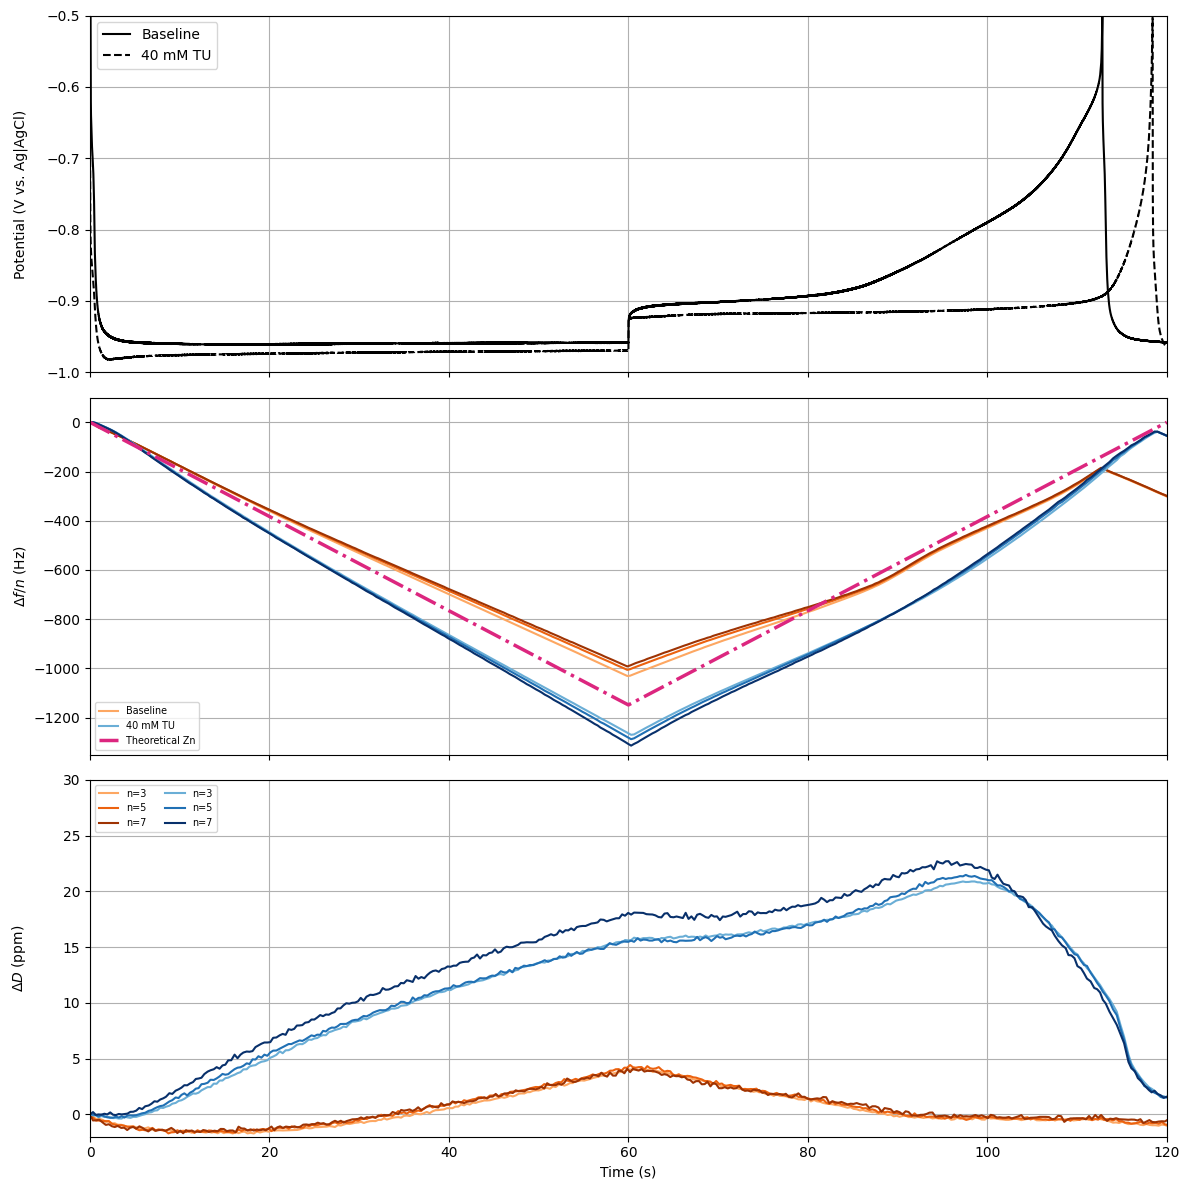

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- File Paths ---
# Experiment 1
name_1 = 'PlatingAndStripping_Zn_on_copper'
potential_file_1 = r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260428 baseline repeat\mp_cycling_baseline_PS.csv"
qcm_file_1 = r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260428 baseline repeat\mp_cycling_baseline.csv"

# Experiment 2 (New)
potential_file_2 = r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260526 Zn TU Cu sensor pH AgCl\mp_cycling_PS.csv"
qcm_file_2 = r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260526 Zn TU Cu sensor pH AgCl\mp_cycling.csv"

# --- 1. Load and Clean Potential Data ---
def load_pot(file, skip=5, enc='utf-16'):
    # Try different encodings if utf-16 fails
    try:
        df = pd.read_csv(file, skiprows=skip, encoding=enc)
    except:
        df = pd.read_csv(file, skiprows=skip, encoding='utf-16')
    df['s'] = pd.to_numeric(df['s'], errors='coerce')
    df['V'] = pd.to_numeric(df['V'], errors='coerce')
    return df.dropna(subset=['s', 'V'])

pot_df_1 = load_pot(potential_file_1, enc='utf-16')
pot_df_2 = load_pot(potential_file_2, enc='utf-16')

# --- 2. Load and Preprocess QCM Data ---
def preprocess(df, start_idx, time_column):
    df = df.iloc[start_idx:].reset_index(drop=True)
    df[time_column] = df[time_column] - df[time_column].iloc[0]
    return df

QCM_df_1 = preprocess(pd.read_csv(qcm_file_1), 0, 'Time_3')
QCM_df_2 = preprocess(pd.read_csv(qcm_file_2), 2, 'Time_3')

# --- 3. Create Figure ---
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(12, 12), sharex=True, 
                                     gridspec_kw={'height_ratios': [2, 2, 2]})

overtones = ['3', '5', '7']
time_column = 'Time_3'

# Color Palettes (Colorblind friendly)
exp1_colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(overtones)))
exp2_colors = plt.cm.Blues(np.linspace(0.5, 1, len(overtones)))

# ----- Subplot 0: Potential (E vs t) -----
ax0.plot(pot_df_1['s'], pot_df_1['V'], color='black', label='Baseline', linestyle='-')
ax0.plot(pot_df_2['s'], pot_df_2['V'], color='black', label='40 mM TU', linestyle='--')
ax0.set_ylabel(r'Potential (V vs. Ag|AgCl)')
ax0.grid(True)

# ----- Subplots 1 & 2: QCM Data (Frequency & Dissipation) -----
for i, overtone in enumerate(overtones):
    f_col, d_col = f'Fr_{overtone}', f'D_{overtone}'
    
    # Plot Exp 1 (Oranges)
    freq1 = (QCM_df_1[f_col] - QCM_df_1[f_col].iloc[0]) / int(overtone)
    diss1 = QCM_df_1[d_col] - QCM_df_1[d_col].iloc[0]
    if i == 0:
        ax1.plot(QCM_df_1[time_column], freq1, color=exp1_colors[i], label='Baseline')
    else:
        ax1.plot(QCM_df_1[time_column], freq1, color=exp1_colors[i])    
    ax2.plot(QCM_df_1[time_column], diss1, color=exp1_colors[i], label=f'n={overtone}')

for i, overtone in enumerate(overtones):
    f_col, d_col = f'Fr_{overtone}', f'D_{overtone}'

    # Plot Exp 2 (Blues)
    freq2 = (QCM_df_2[f_col] - QCM_df_2[f_col].iloc[0]) / int(overtone)
    diss2 = QCM_df_2[d_col] - QCM_df_2[d_col].iloc[0]
    if i == 0:
        ax1.plot(QCM_df_2[time_column], freq2, color=exp2_colors[i], label ='40 mM TU')
    else:
        ax1.plot(QCM_df_2[time_column], freq2, color=exp2_colors[i])
    ax2.plot(QCM_df_2[time_column], diss2, color=exp2_colors[i], label=f'n={overtone}')

#TODO: @Albin - Here you need to provide the option to select all parameters except F which is an absolute constant

# Constants from your experiment
j = 1.0e-3          # Current density (A/cm^2)
A = 1.13            # Area (cm^2)
M_Zn = 65.38        # Molar mass Zinc (g/mol)
z = 2               # Valency
F = 96485           # Faraday constant (C/mol)
sensitivity = 17.7  # ng/Hz/cm^2
time_total = 60     # seconds

# 1. Calculate the theoretical slope (Hz per second)
# mass_rate (g/s) = (I * M) / (z * F)
current = j * A
mass_rate_g_s = (current * M_Zn) / (z * F)
mass_rate_ng_s = mass_rate_g_s * 1e9

# frequency_slope (Hz/s) = (mass_rate / area) / sensitivity
freq_slope = (mass_rate_ng_s / A) / sensitivity

# --- Time Segments ---
t_plating = np.linspace(0, 60, 100)
t_stripping = np.linspace(60, 120, 100)
t_full = np.concatenate([t_plating, t_stripping])

# Segment 1: Plating (0-60s) -> Frequency goes down
f_plating = -freq_slope * t_plating

f_start_stripping = f_plating[-1]
f_stripping = f_start_stripping + freq_slope * (t_stripping - 60)

f_total = np.concatenate([f_plating, f_stripping])

ax1.plot(t_full, f_total, color='#DC267F',linestyle='-.',linewidth=2.5, label=f'Theoretical Zn')

# Formatting
ax1.set_ylabel('$\Delta f / n$ (Hz)')
ax2.set_ylabel('$\Delta D$ (ppm)')
ax2.set_xlabel('Time (s)')

# Clean up legend (put it outside or make it smaller if it's too crowded)
ax0.legend(loc='upper left')
ax1.legend(loc='lower left', ncol=1, fontsize='x-small')
ax2.legend(loc='upper left', ncol=2, fontsize='x-small')

ax1.grid(True)
ax2.grid(True)

# Set Axis Limits
#TODO: @Albin - Having the option to adjust plots based on values like this is also immensily useful! 
#      Rather than absolute values for the time (x-axis) I prefer cycles but this is not strictly true and sometimes time needs to be chosen
#      So preferably one can switch between these at choice
ax0.set_xlim(0, 120)
ax0.set_ylim(-1, -0.5)
ax1.set_ylim(-1350, 100)
ax2.set_ylim(-2,30)

fig.align_ylabels([ax0, ax1, ax2])

plt.tight_layout()
plt.show()

Static mpe readout over an entire plating or stripping cycle

<>:34: SyntaxWarning: invalid escape sequence '\M'
<>:34: SyntaxWarning: invalid escape sequence '\M'
C:\Users\vikva795\AppData\Local\Temp\ipykernel_2184\112710657.py:34: SyntaxWarning: invalid escape sequence '\M'
  """
C:\Users\vikva795\AppData\Local\Temp\ipykernel_2184\112710657.py:55: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  ps_raw = pd.read_csv(ps_path, encoding='utf-16', skiprows=5)
C:\Users\vikva795\AppData\Local\Temp\ipykernel_2184\112710657.py:55: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  ps_raw = pd.read_csv(ps_path, encoding='utf-16', skiprows=5)
C:\Users\vikva795\AppData\Local\Temp\ipykernel_2184\112710657.py:55: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  ps_raw = pd.read_csv(ps_path, encoding='utf-16', skiprows=5)


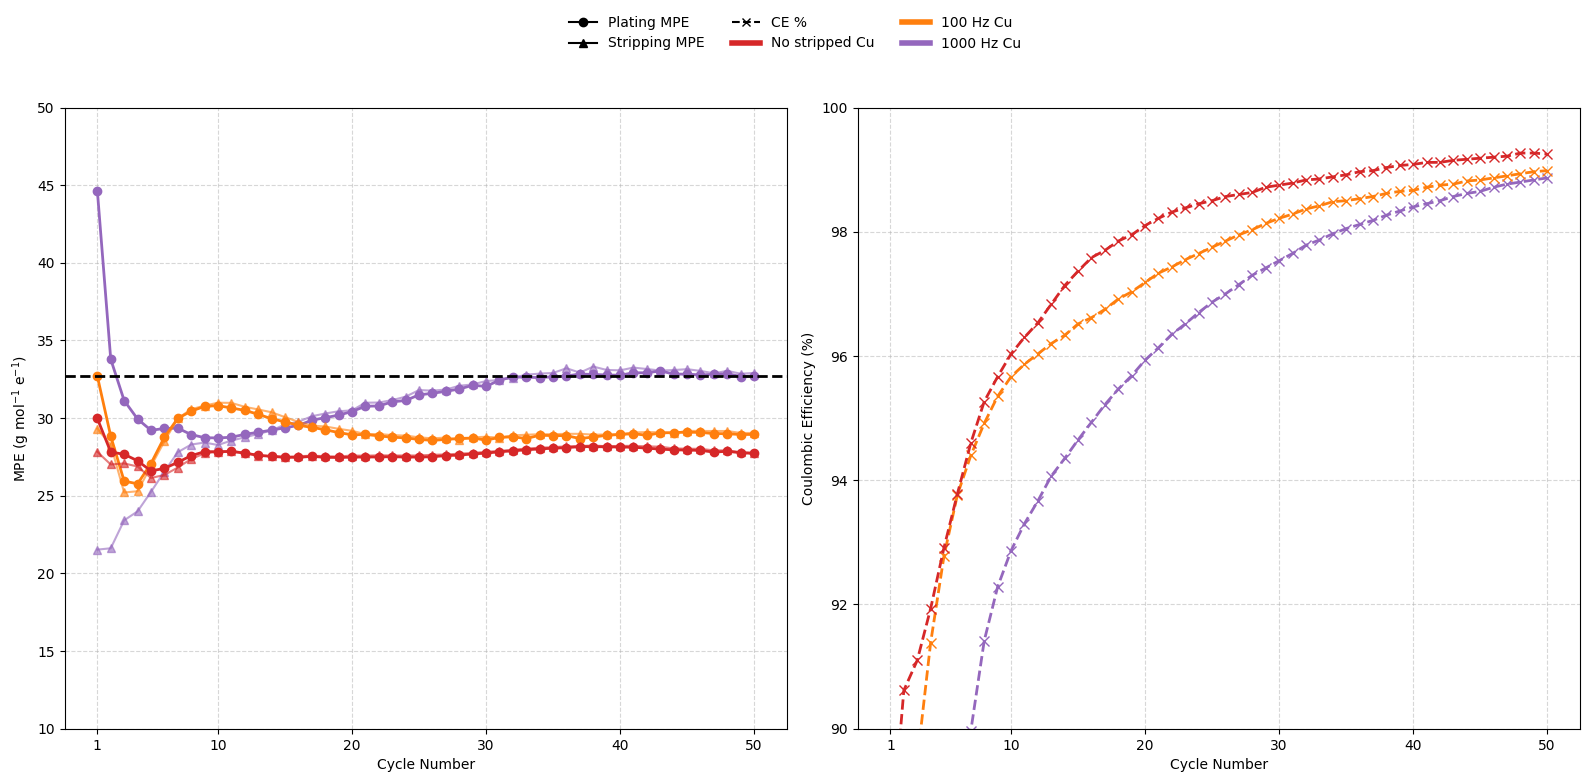

In [ ]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl

# --- CONSTANTS ---
F = 96485
f0 = 4.95E6
rho_q = 2.65
mu_q = 2.9471E+11
area = (0.6**2) * math.pi

#TODO: @Albin - just delete the files I haven't provided :)

# --- DATA FILES ---
datasets = {
    "1.2 M ZnCl$_2$ + 1 M ZnSO$_4$ + 40 mM TU + 1000 Hz Cu": {
        "qcm": r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260428 baseline Cu from stripping 1000 Hz\mp_cycling.csv",
        "ps": r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260428 baseline Cu from stripping 1000 Hz\mp_cycling_PS.csv",
        "color": "tab:purple"
    },
    "1.2 M ZnCl$_2$ + 1 M ZnSO$_4$ + 40 mM TU + 100 Hz Cu": {
        "qcm": r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260427 baseline Cu from stripping 100 Hz\mp_cycling.csv",
        "ps": r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260427 baseline Cu from stripping 100 Hz\mp_cycling_PS.csv",
        "color": "tab:orange"
    },
    "1.2 M ZnCl$_2$ + 1 M ZnSO$_4$ + 40 mM TU": {
        "qcm": r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260428 baseline repeat\mp_cycling_baseline.csv",
        "ps": r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260428 baseline repeat\mp_cycling_baseline_PS.csv",
        "color": "tab:red"
    },
}

"""
    "1.2 M ZnCl$_2$ + 1 M ZnSO$_4$ + 40 mM TU + 500 Hz Cu": {
        "qcm": r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260427 baseline Cu from stripping 500 Hz\mp_cycling.csv",
        "ps": r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260427 baseline Cu from stripping 500 Hz\mp_cycling_PS.csv",
        "color": "tab:blue"
    },
"""

# --- PROCESSING FUNCTION ---
def process_eqcm_data(qcm_path, ps_path, start_time=0, end_time=6000):
    scale = area * F * np.sqrt(rho_q * mu_q) / (2 * f0**2) * 1e6 # µg/C
    
    try:
        qcm = pd.read_csv(qcm_path)
    except Exception:
        return pd.DataFrame()

    qcm = qcm[(qcm['Time_1'] >= start_time) & (qcm['Time_1'] <= end_time)].copy()
    qcm['Time_1'] = qcm['Time_1'] - qcm['Time_1'].iloc[0]

    try:
        ps_raw = pd.read_csv(ps_path, encoding='utf-16', skiprows=5)
    except:
        ps_raw = pd.read_csv(ps_path, skiprows=5)
        
    for col in ["s", "µC", "µA"]:
        ps_raw[col] = pd.to_numeric(ps_raw[col], errors="coerce")
    ps_raw = ps_raw.dropna(subset=["s"])

    c_df = ps_raw[(ps_raw["s"] >= start_time) & (ps_raw["s"] <= end_time)].copy()
    c_df["s"] = c_df["s"] - c_df["s"].iloc[0]

    qcm["Charge_interp"] = np.interp(qcm["Time_1"].astype(float), c_df["s"].values, c_df["µC"].values)

    ps_cyc = c_df.copy()
    ps_cyc["sign"] = np.sign(ps_cyc["µA"]).replace(0, np.nan).ffill().bfill()

    is_plating = (ps_cyc["sign"].shift(1) > 0) & (ps_cyc["sign"] < 0)
    is_stripping = (ps_cyc["sign"].shift(1) < 0) & (ps_cyc["sign"] > 0)

    p_starts = ps_cyc.loc[is_plating, "s"].values.tolist()
    s_starts = ps_cyc.loc[is_stripping, "s"].values.tolist()

    if len(ps_cyc) > 0:
        if ps_cyc["sign"].iloc[0] < 0: p_starts.insert(0, ps_cyc["s"].iloc[0])
        elif ps_cyc["sign"].iloc[0] > 0: s_starts.insert(0, ps_cyc["s"].iloc[0])

    p_starts, s_starts = np.array(p_starts), np.array(s_starts)
    results = []

    def calc_mpe(t0, t1, df):
        sub = df[(df["Time_1"] >= t0) & (df["Time_1"] <= t1)]
        if len(sub) < 2: return np.nan
        dF = (sub["Fr_3"].iloc[-1] - sub["Fr_3"].iloc[0])/3
        dQ = sub["Charge_interp"].iloc[-1] - sub["Charge_interp"].iloc[0]
        return (dF / dQ) * scale if abs(dQ) > 1e-4 else np.nan

    for i in range(len(p_starts)):
        t_p = p_starts[i]
        future_s = s_starts[s_starts > t_p]
        if len(future_s) == 0: continue
        t_s = future_s[0]
        
        future_p = p_starts[p_starts > t_s]
        t_e = future_p[0] if len(future_p) > 0 else ps_cyc["s"].iloc[-1]

        dt_p, dt_s = t_s - t_p, t_e - t_s
        results.append({
            "Cycle": i + 1,
            "MPE_Plating": calc_mpe(t_p, t_s, qcm),
            "MPE_Stripping": calc_mpe(t_s, t_e, qcm),
            "CE_Percent": (dt_s / dt_p) * 100 if dt_p > 0 else np.nan
        })
    return pd.DataFrame(results)

# --- EXECUTION ---
results_dict = {}
for name, paths in datasets.items():
    results_dict[name] = process_eqcm_data(paths["qcm"], paths["ps"])

# --- PLOTTING ---
fig, (ax_mpe, ax_ce) = plt.subplots(1, 2, figsize=(16, 7))

for name, data in results_dict.items():
    if data.empty: continue
    data = data[data["Cycle"] <= 50]
    color = datasets[name]["color"]
    
    # Left Panel: MPE
    ax_mpe.plot(data["Cycle"], data["MPE_Plating"], color=color, marker='o', ls='-', lw=2, ms=6)
    ax_mpe.plot(data["Cycle"], data["MPE_Stripping"], color=color, marker='^', ls='-', lw=1.5, ms=6, alpha=0.6)
    
    # Right Panel: CE
    ax_ce.plot(data["Cycle"], data["CE_Percent"], color=color, marker='x', ls='--', lw=2, ms=7)

# Formatting
ax_mpe.set_ylabel('MPE (g mol$^{-1}$ e$^{-1}$)')
ax_mpe.set_ylim(10, 50)
ax_mpe.axhline(y=32.69, color='black', ls='--', lw=2)

ax_ce.set_ylabel('Coulombic Efficiency (%)')
ax_ce.set_ylim(90, 100)

for ax in [ax_mpe, ax_ce]:
    ax.set_xlabel('Cycle Number')
    ax.grid(True, ls='--', alpha=0.5)
    ax.set_xticks([1, 10, 20, 30, 40, 50])

# Legend
h_p = Line2D([0], [0], color='black', marker='o', ls='-', label='Plating MPE')
h_s = Line2D([0], [0], color='black', marker='^', ls='-', label='Stripping MPE')
h_c = Line2D([0], [0], color='black', marker='x', ls='--', label='CE %')
h_1000 = Line2D([0], [0], color='tab:purple', lw=4, label='1000 Hz Cu')
h_100 = Line2D([0], [0], color='tab:orange', lw=4, label='100 Hz Cu')
h_0 = Line2D([0], [0], color='tab:red', lw=4, label='No stripped Cu')

fig.legend(handles=[h_p, h_s, h_c, h_0, h_100, h_1000 ], loc='upper center', 
           bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

Below is an example for a dynamic mpe readout.

To filter the mpe data (it will look very noisy) preferably use:
**from scipy.signal import savgol_filter**

[28.75512017 30.17102339 33.9009366  ... 30.54242236 30.50885569
 29.59930718]
0           0.00
1           0.33
2           0.67
3           1.01
4           1.43
          ...   
17800    5856.01
17801    5856.34
17802    5856.73
17803    5857.06
17804    5857.40
Name: Time_1, Length: 17805, dtype: float64


C:\Users\vikva795\AppData\Local\Temp\ipykernel_2184\3669147123.py:27: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  PSTrace = pd.read_csv(r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260428 baseline repeat\mp_cycling_baseline_PS.csv",encoding='utf-16', skiprows=5)


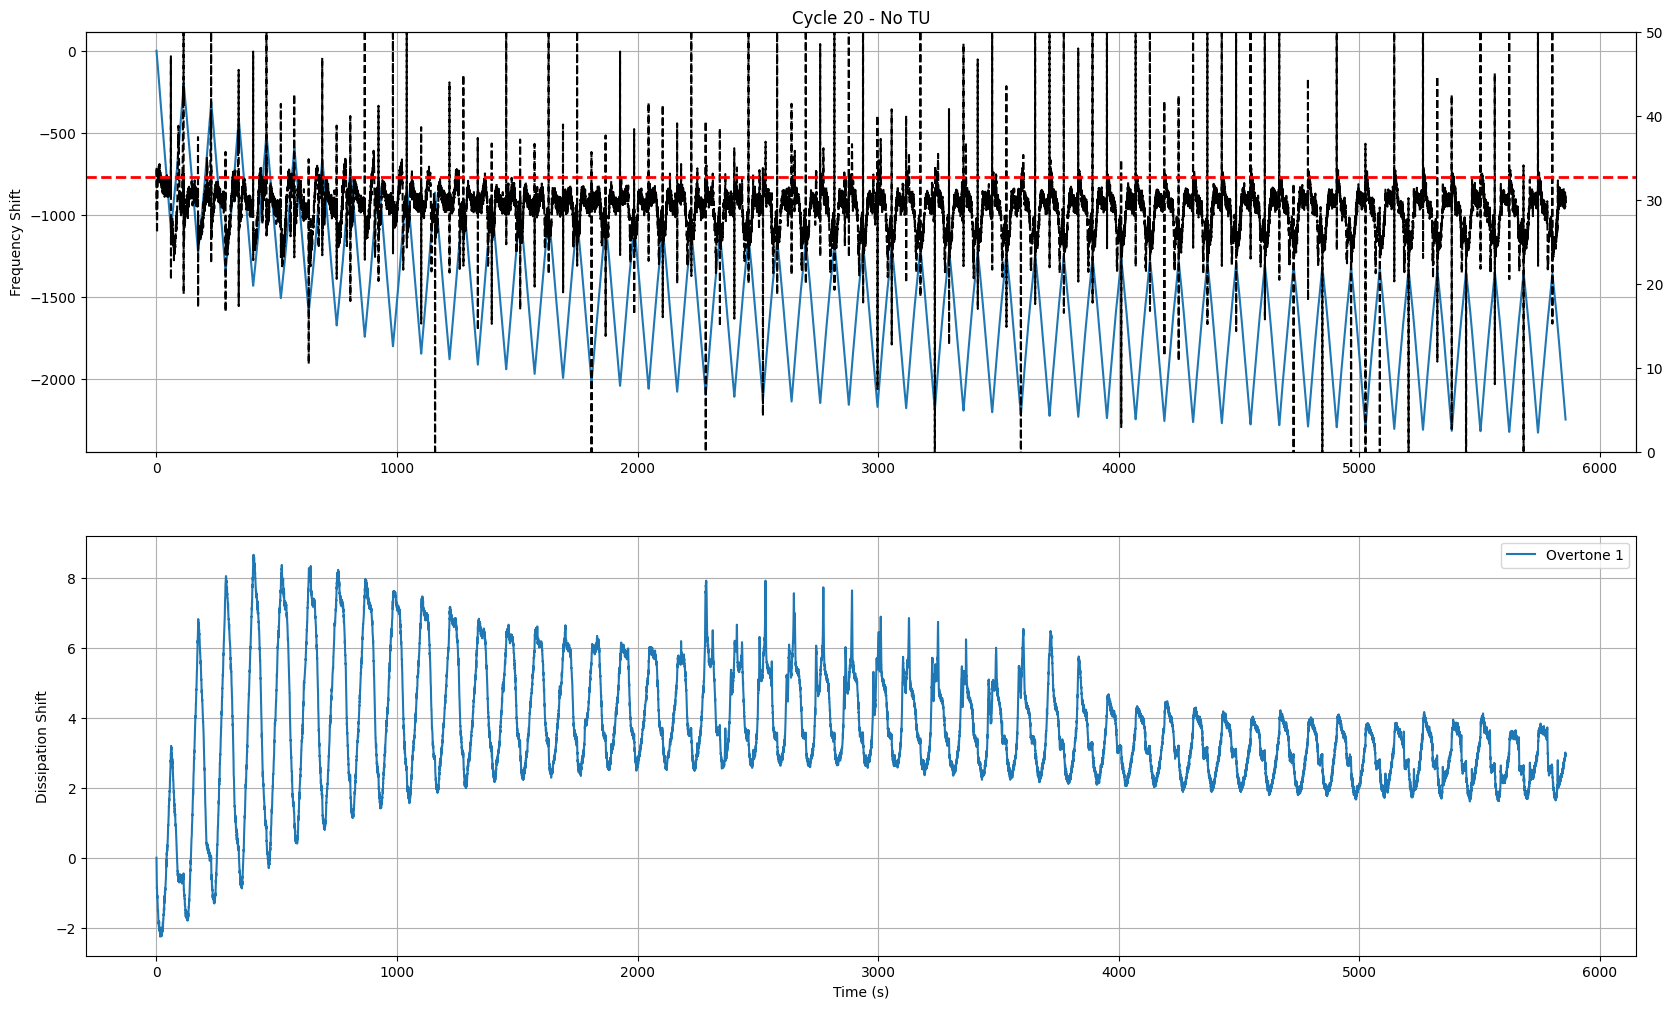

In [ ]:
import numpy as np
import math
import pandas as pd

F = 96485  # Faraday constant
f0 = 4.95E6  # Base frequency
rho_q = 2.65
mu_q = 2.9471E+11
area = (0.6**2) * math.pi

#QCM_df = pd.read_csv(r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260113 Zinc Thiourea\TU\mp 20 cycles.csv")
QCM_df = pd.read_csv(r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260428 baseline repeat\mp_cycling_baseline.csv")

start_time = 0
end_time = 5858


# Filter the DataFrame
QCM_df = QCM_df[(QCM_df[f'Time_1'] >= start_time) & (QCM_df['Time_1'] <= end_time)]

QCM_df['Time_1'] = QCM_df['Time_1'] - QCM_df['Time_1'].iloc[0]



# Load and clean charge data
#PSTrace = pd.read_csv(r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260113 Zinc Thiourea\TU\mp 20 cycles_PS.csv",encoding='utf-16', skiprows=5)
PSTrace = pd.read_csv(r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260428 baseline repeat\mp_cycling_baseline_PS.csv",encoding='utf-16', skiprows=5)

#print(PSTrace.head())

C_100mV = pd.DataFrame()
C_100mV["Time"] = PSTrace["s"]
C_100mV["Charge"] = PSTrace["µC"]

C_100mV.columns = C_100mV.columns.str.replace('\ufeff', '')
C_100mV["Time"] = pd.to_numeric(C_100mV["Time"], errors='coerce')
C_100mV["Charge"] = pd.to_numeric(C_100mV["Charge"], errors='coerce')
C_100mV = C_100mV.dropna(subset=["Time", "Charge"])
C_100mV["Charge_C"] = C_100mV["Charge"]

# Interpolate charge to QCM time base
QCM_df["Charge_interp"] = np.interp(
    QCM_df["Time_1"].astype(float),
    C_100mV["Time"].values,
    C_100mV["Charge_C"].values
)

# Compute pointwise differences instead of cumulative
delta_f = np.gradient(QCM_df["Fr_1"]) / overtone 
delta_Q = np.gradient(QCM_df["Charge_interp"])

# MPE scaling factor
scale = area * F * np.sqrt(rho_q * mu_q) / (2 * f0**2) * 1e6 # µg/C

# Calculate MPE at each time step (Δf / ΔQ)
with np.errstate(divide='ignore', invalid='ignore'):
    mpe = np.where(delta_Q != 0, delta_f / delta_Q * scale, np.nan)

QCM_df["MPE_1"] = mpe
tim = QCM_df["Time_1"]
print(mpe)
print(tim)

import matplotlib.pyplot as plt

# Define overtones
overtones = [1]

fig = plt.figure(figsize=(20, 12))
ax1 = plt.subplot(2, 1, 1)
ax1b = ax1.twinx()  # Twin y-axis for MPE

for overtone in overtones:
    time_col = f'Time_{overtone}'
    freq_col = f'Fr_{overtone}'

    # Normalize frequency and time
    QCM_df[freq_col] = (QCM_df[freq_col] - QCM_df[freq_col].iloc[0]) / overtone

    QCM_df[time_col] = QCM_df[time_col] - QCM_df[time_col].iloc[0]

    ax1.plot(QCM_df[time_col], QCM_df[freq_col], linestyle='-') #, marker='o'
"""
# Step A: Clip Outliers
# Real MPE should be around 32.5 (Zn). Values like +/- 1000 are math artifacts.
# We clip the data to a generous range (e.g., -100 to +150) to remove the huge spikes.
QCM_df["MPE_Clipped"] = mpe.clip(-100, 150)

# Step B: Smoothing (Rolling Mean)
# 'window' is the number of points to average. Increase this if it's still too noisy.
window_size = 50
QCM_df["MPE_Smooth"] = QCM_df["MPE_Clipped"].rolling(window=window_size, center=True, min_periods=5).mean()
"""
# Plot MPE on twin axis
ax1b.plot(QCM_df["Time_1"], mpe, label="MPE", color='black', linestyle='--')

# Axis labels and legend
ax1.set_ylabel('Frequency Shift')
ax1.set_title('Cycle 20 - No TU')
ax1.grid(True)

ax1b.set_ylim(0,50)
ax1b.axhline(y=32.69, color='r', linestyle='--', linewidth=2)
#TODO: @Albin - This axhline is the target mpe which one should be able to choose and toggle on or off

# Plot dissipation shifts
ax2 = plt.subplot(2, 1, 2)
for overtone in overtones:
    time_col = f'Time_{overtone}'
    diss_col = f'D_{overtone}'

    # Normalize dissipation
    QCM_df[diss_col] = QCM_df[diss_col] - QCM_df[diss_col].iloc[0]

    ax2.plot(QCM_df[time_col], QCM_df[diss_col], label=f'Overtone {overtone}', linestyle='-')

ax2.set_ylabel('Dissipation Shift')
ax2.set_xlabel('Time (s)')
ax2.grid(True)
ax2.legend(loc='upper right')


#ax1.set_xlim(100,240)
#ax2.set_xlim(100,240)


# Cyclic voltammetry experiments

Here the situation is reversed compared to below and slightly different. Rather than selecting a fixed potential we start at a given potential and then move it with a sweep rate (V/s) which can be used to convert the x between time and voltage. The measured response is the current in response to this changing potential.

As discussed, experiments for cyclic voltammetry will often have a number cycles or repeats. Similar to above it would be good to dynamically split these. Once again alignment is a challenge to deal with. A cycle in the data is defined as a new column. Converting the potential to time helps with knowing when a new cycle has started from the potentiostat in the EQCM data which is time based.

What is required is similar to above but also the ability to plot versus potential rather than time (although swithcing between both would be great, just in case!)

- Once again, selecting cycles is nice and comparing different or the same cycles from different data files is nice.
- Being able to zoom in on small features in the CV is also good, the provided plot does this via zoom insets (which will not work that well for dynamic plotting)
- Regarding the MPE, only the dynamic MPE here makes sense so don't worry about the static mpe per cycle.
- Indicating in which way the data is moving through arrows is a good thing to do, I haven't added that yet here.

C:\Users\vikva795\AppData\Local\Temp\ipykernel_2184\4045365892.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


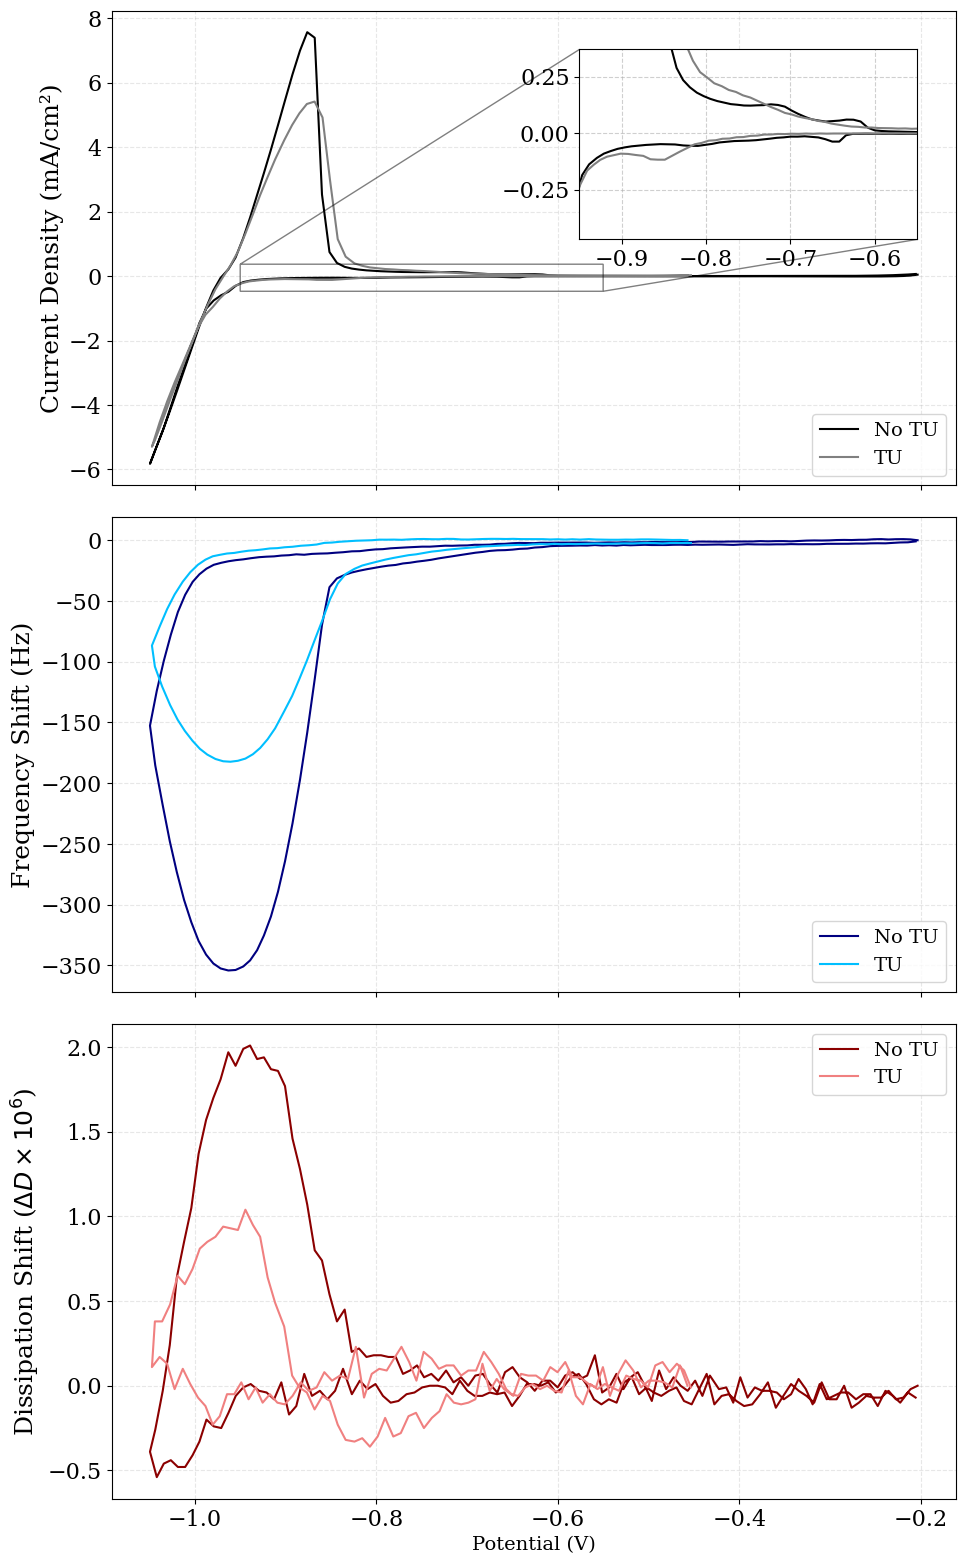

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import math
import re

# --- 1. Constants ---
F = 96485
f0 = 4.95E6
rho_q = 2.65
mu_q = 2.9471E+11
area = (0.6**2) * math.pi

# --- 2. Data Processing Function ---
def process_eqcm_data(cv_file, qcm_file):
    # Load QCM data
    qcm_df = pd.read_csv(qcm_file)

    # Load CV data and parse the dynamic header for column assignments
    try:
        cv_df = pd.read_csv(cv_file, skiprows=6, header=None)
        with open(cv_file, 'r', encoding='utf-8', errors='ignore') as f:
            lines = [f.readline().strip() for _ in range(5)]
    except:
        cv_df = pd.read_csv(cv_file, skiprows=6, header=None, encoding="utf-16")
        with open(cv_file, 'r', encoding='utf-16', errors='ignore') as f:
            lines = [f.readline().strip() for _ in range(5)]

    for col in cv_df.columns:
        cv_df[col] = pd.to_numeric(cv_df[col], errors='coerce')

    # Dynamically locate the correct Potential and Current columns from the header
    header_line = lines[3].split(',')
    scan_indices = []
    for idx, col_name in enumerate(header_line):
        if 'CV i vs E Scan' in col_name:
            # Potential is at idx, Current is at idx + 1
            scan_indices.append((idx, idx + 1))

    # Extract Scan Rate from Filename
    match = re.search(r'(\d+)mVs', cv_file)
    if match:
        scan_rate = float(match.group(1)) / 1000.0
    else:
        scan_rate = 0.025 # Fallback default in V/s

    # Stitch Scans (Calculates Time Dynamically)
    stitched_time = []
    stitched_potential = []
    stitched_current = []
    cycle_end_times = {} 
    cumulative_time = 0

    for c_num, (col_pot, col_cur) in enumerate(scan_indices, start=1):
        if col_cur >= len(cv_df.columns): break

        scan_data = cv_df[[col_pot, col_cur]].dropna()
        if scan_data.empty: continue

        pot = scan_data[col_pot].values
        cur = scan_data[col_cur].values
        
        # Calculate time based on dV / scan_rate 
        time = [0.0]
        for j in range(1, len(pot)):
            dV = abs(pot[j] - pot[j-1])
            dt = dV / scan_rate
            time.append(time[-1] + dt)
        time = np.array(time)
        
        time_adjusted = time + cumulative_time

        stitched_time.extend(time_adjusted)
        stitched_potential.extend(pot)
        stitched_current.extend(cur)

        if len(time) > 0:
            cumulative_time = time_adjusted[-1]
            cycle_end_times[c_num] = cumulative_time

    stitched_cv = pd.DataFrame({
        'Time': stitched_time,
        'Potential': stitched_potential,
        'Current_uA': stitched_current
    })

    # Load & Process QCM Data within CV bounds
    t_start = stitched_cv['Time'].min()
    t_end = stitched_cv['Time'].max()

    qcm_data = qcm_df[(qcm_df['Time_1'] >= t_start) & (qcm_df['Time_1'] <= t_end)].copy()
    qcm_time = qcm_data['Time_1'].values

    # Interpolation & Cycle Assignment
    qcm_data['Potential'] = np.interp(qcm_time, stitched_cv['Time'], stitched_cv['Potential'])
    qcm_data['Current_uA'] = np.interp(qcm_time, stitched_cv['Time'], stitched_cv['Current_uA'])

    qcm_data['Cycle'] = 1
    for c in range(1, len(cycle_end_times)):
        t_boundary = cycle_end_times[c]
        qcm_data.loc[qcm_data['Time_1'] > t_boundary, 'Cycle'] = c + 1

    # Calc Density
    qcm_data['Current_Density'] = (qcm_data['Current_uA'] / 1000.0) / area

    # Process Frequency & Dissipation (Overtone 3)
    overtone = 3
    freq_col = f'Fr_{overtone}'
    diss_col = f'D_{overtone}'

    if not qcm_data.empty:
        f_start = qcm_data[freq_col].iloc[0]
        d_start = qcm_data[diss_col].iloc[0]

        qcm_data['Freq_Shift'] = (qcm_data[freq_col] - f_start) / overtone
        qcm_data['Diss_Shift'] = (qcm_data[diss_col] - d_start)
    
    return qcm_data


# --- 3. Load Datasets ---
# Update paths for dataset 1
cv_file_1 = r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260527 Zn TU Cu sensor CV\no TU\CV_-1050mV_-200mV_25mVs_PS.csv"
qcm_file_1 = r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260527 Zn TU Cu sensor CV\no TU\CV_-1050mV_-200mV_25mVs.csv"

# Dataset 2
cv_file_2 = r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260527 Zn TU Cu sensor CV\TU\CV_-1050mV_-450mV_25mVs_PS.csv"
qcm_file_2 = r"\\argos.storage.uu.se\MyFolder$\vikva795\Import-from-POL\InterphasesDrive - Viktor projects\Python_251104\EQCM plotting\260527 Zn TU Cu sensor CV\TU\CV_-1050mV_-450mV_25mVs.csv"

# Process both datasets
data_1 = process_eqcm_data(cv_file_1, qcm_file_1)
data_2 = process_eqcm_data(cv_file_2, qcm_file_2)


# --- 4. Plotting ---
datasets_to_plot = [
    {'name': 'No TU', 'data': data_1, 'colors': {'curr': 'black', 'freq': 'navy', 'diss': 'darkred'}},
    {'name': 'TU', 'data': data_2, 'colors': {'curr': 'gray', 'freq': 'deepskyblue', 'diss': 'lightcoral'}}
]

fig, axes = plt.subplots(3, 1, figsize=(10, 16), sharex=True)

# Formatting
axes[0].set_ylabel('Current Density (mA/cm²)')
axes[0].grid(True)

axes[1].set_ylabel('Frequency Shift (Hz)')
axes[1].grid(True)

axes[2].set_ylabel(r'Dissipation Shift ($\Delta D \times 10^6$)')
axes[2].set_xlabel('Potential (V)', fontsize=14)
axes[2].grid(True)


# Setup Inset Axes for Current Density (ax[0])
axins = inset_axes(axes[0], width="40%", height="40%", loc='upper right', borderpad=2)


# Loop over the configured datasets
for item in datasets_to_plot:
    dataset_name = item['name']
    df = item['data']
    c_colors = item['colors']
    
    # Isolate ONLY Cycle 3 and use .copy() to avoid setting on a slice warning
    cycle3_data = df[df['Cycle'] == 3].copy()
    
    if cycle3_data.empty: 
        continue
        
    # Baseline Frequency and Dissipation relative to the start of Cycle 3
    cycle3_data['Freq_Shift'] = cycle3_data['Freq_Shift'] - cycle3_data['Freq_Shift'].iloc[0]
    cycle3_data['Diss_Shift'] = cycle3_data['Diss_Shift'] - cycle3_data['Diss_Shift'].iloc[0]
        
    # Main Plots
    axes[0].plot(cycle3_data['Potential'], cycle3_data['Current_Density'], 
                 color=c_colors['curr'], label=f'{dataset_name}')
    axes[1].plot(cycle3_data['Potential'], cycle3_data['Freq_Shift'], 
                 color=c_colors['freq'], label=f'{dataset_name}')
    axes[2].plot(cycle3_data['Potential'], cycle3_data['Diss_Shift'], 
                 color=c_colors['diss'], label=f'{dataset_name}')
              
    # Inset Plot (Only for Current vs Potential)
    axins.plot(cycle3_data['Potential'], cycle3_data['Current_Density'], color=c_colors['curr'])


# Set Inset Limits (Zoom from -0.95 to -0.55 V)
axins.set_xlim(-0.95, -0.55)

# Hardcoded bounds as requested
ymin, ymax = -0.4, 0.3
margin = (ymax - ymin) * 0.1
axins.set_ylim(ymin - margin, ymax + margin)

axins.grid(True, linestyle='--', alpha=0.6)

# Draw connecting lines from the zoomed area on the main plot to the inset
axes[0].indicate_inset_zoom(axins, edgecolor="black")

# Assign legends per subplot
axes[0].legend(loc='lower right')
axes[1].legend(loc='best')
axes[2].legend(loc='best')

plt.tight_layout()
plt.show()

# Future work

If you have all of this in place, that's already quite impressive! Slack me and I will see whether I can think of more features to add :)